In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

import xgboost as xgb

In [61]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print("WYNIKI MODELU")
    print(f"R^2 Score: {r2:.4f}")
    print(f"MAE:        ${mae:,.2f}")
    print(f"RMSE:       ${rmse:,.2f}")
    print(f"std:        ${np.std(y_test):,.2f}")

    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred, alpha=0.4)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.title("Predicted vs Actual Movie Revenue")
    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.grid(True)
    plt.show()

    return mae, rmse, r2

In [ ]:
def evaluate_model_complex(y_test, y_pred):
    residuals = y_test - y_pred

    plt.figure(figsize=(8,6))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, linestyle='--')
    plt.title("Residuals vs Predicted")
    plt.xlabel("Predicted")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(8,6))
    plt.hist(residuals, bins=50)
    plt.title("Distribution of Residuals")
    plt.xlabel("Error")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, residuals, alpha=0.4)
    plt.axhline(0, linestyle='--')
    plt.title("Residuals vs Actual Revenue")
    plt.xlabel("Actual Revenue")
    plt.ylabel("Residuals")
    plt.grid(True)
    plt.show()


    bins = [0, 10e6, 50e6, 100e6, 500e6, 1e9]
    labels = ["<10M", "10-50M", "50-100M", "100-500M", "500M+"]
    df_eval = pd.DataFrame({
        "y": y_test,
        "y_pred": y_pred
    })
    df_eval["bucket"] = pd.cut(df_eval["y"], bins=bins, labels=labels)
    mae_per_bucket = df_eval.groupby("bucket").apply(
        lambda x: np.mean(np.abs(x["y"] - x["y_pred"]))
    )
    mae_per_bucket.plot(kind="bar")
    plt.title("MAE by Revenue Bucket")
    plt.ylabel("MAE")
    plt.show()

In [4]:
data = pd.read_csv('../data/merged/data_model.csv')
data

,runtime,year,budget_adjusted,revenue_adjusted,quarter,director_movie_count,writer_movie_count,actors_avg_movie_count,writer_avg_revenue,writer_max_revenue,...,kw_new_york_city,kw_serial_killer,kw_revenge,kw_musical,kw_high_school,kw_small_town,kw_superhero,kw_alien,kw_biography,kw_fantasy_world
0,98,1995,8.449948e+06,8.993604e+06,4,15,13,8.2,2.384469e+08,5.964630e+08,...,0,0,0,0,0,0,0,0,0,0
1,109,1993,4.678756e+07,2.704085e+07,4,9,9,3.6,7.272651e+07,1.714053e+08,...,0,0,0,0,0,0,0,0,0,0
2,100,2003,1.644709e+08,1.645296e+09,2,9,7,12.4,1.081580e+09,1.645296e+09,...,0,0,0,0,0,0,0,0,0,0
3,142,1994,1.194795e+08,1.471527e+09,2,20,13,21.8,3.225962e+08,1.471527e+09,...,0,0,0,0,0,0,0,0,0,0
4,122,1999,2.898646e+07,6.885186e+08,3,9,1,9.0,6.885186e+08,6.885186e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,137,2025,2.000000e+07,4.227859e+08,3,1,1,1.0,4.227859e+08,4.227859e+08,...,0,0,0,0,0,0,0,0,0,0
9182,224,2025,6.500000e+07,3.500000e+06,4,6,1,2.6,3.500000e+06,3.500000e+06,...,0,0,1,0,0,0,0,0,0,0
9183,88,2023,1.056583e+04,5.599891e+04,2,1,1,1.0,5.599891e+04,5.599891e+04,...,0,0,1,0,0,0,0,0,0,0
9184,127,2025,1.600000e+06,1.472934e+06,4,3,1,1.2,1.472934e+06,1.472934e+06,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(data.shape)
q_low = data['revenue_adjusted'].quantile(0.01)
q_high = data['revenue_adjusted'].quantile(0.99)
data_filtered = data[(data['revenue_adjusted'] >= q_low) & (data['revenue_adjusted'] <= q_high)].copy()
data_filtered.shape

(9186, 88)


(9002, 88)

In [6]:
X = data_filtered.drop(columns=['revenue_adjusted'])
y = data_filtered['revenue_adjusted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model bazowy

In [60]:
scores = []

Model bazowy - średnia
WYNIKI MODELU
R^2 Score: -0.0001
MAE:        $117,578,576.15
RMSE:       $184,825,693.94
std:        $184,818,060.44


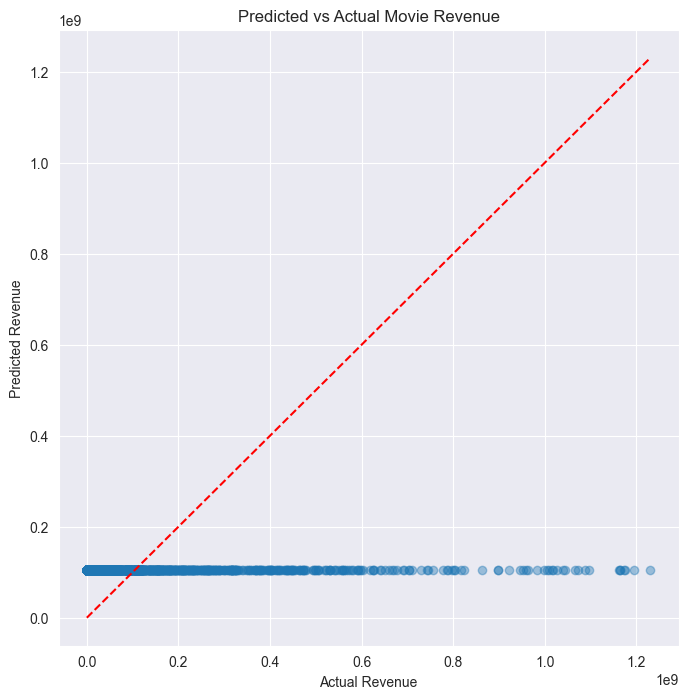

In [13]:
print("Model bazowy - średnia")
mae, rmse, r2 = evaluate_model(y_test, np.full_like(y_test, np.mean(y_train)))
scores.append({
    "model": "baseline",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

## Regresja liniowa

Prosta regresja liniowa tworzy model wyjaśnialny w 74%, MAE jest mniejszy od odchylenia standardowego, ale i tak jest znaczące.

WYNIKI MODELU
R^2 Score: 0.7496
MAE:        $55,695,428.12
RMSE:       $92,489,832.89
std:        $184,818,060.44


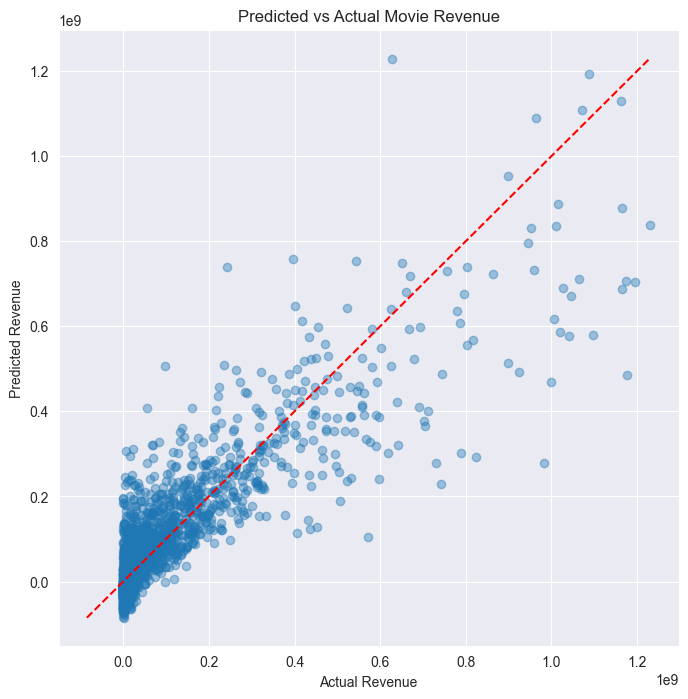

In [63]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "linear regression",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

## RandomForest

Najlepszy uzyskany model, najniższe MAE 28,17 mln.

WYNIKI MODELU
R^2 Score: 0.8810
MAE:        $28,170,603.30
RMSE:       $63,753,975.90
std:        $184,818,060.44


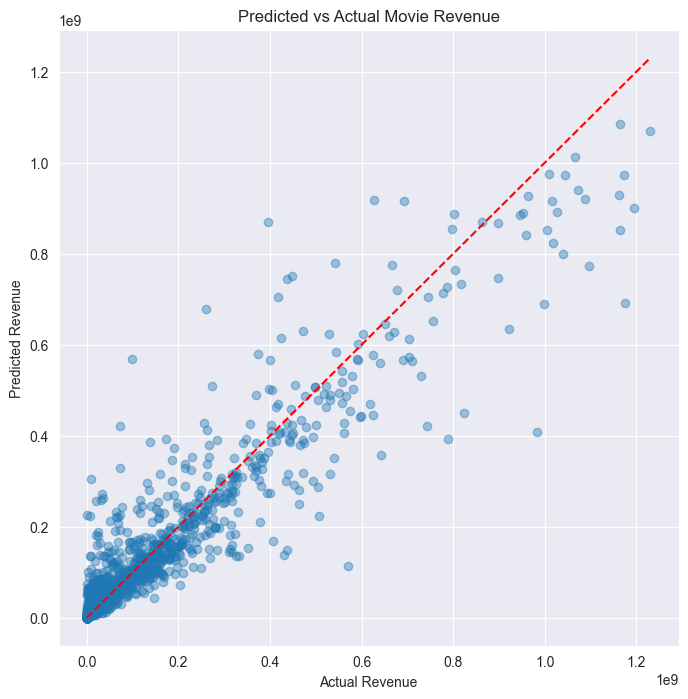

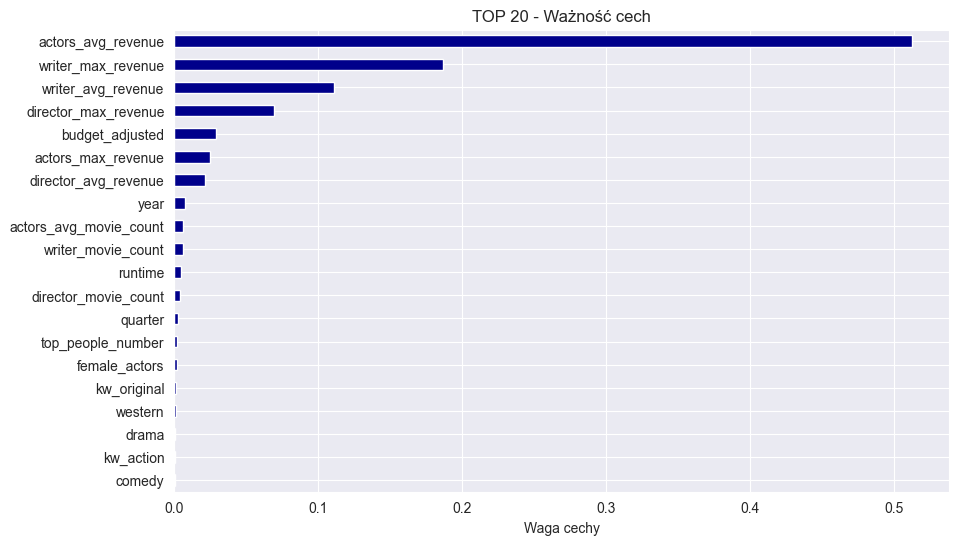

In [64]:
rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

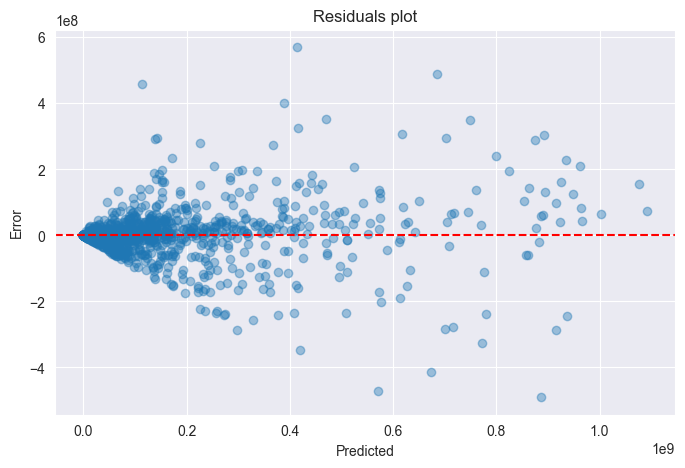

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

Wybór najbardziej znaczących cech - odrobinę lepszy model

WYNIKI MODELU
R^2 Score: 0.8836
MAE:        $28,025,817.77
RMSE:       $63,051,489.30
std:        $184,818,060.44


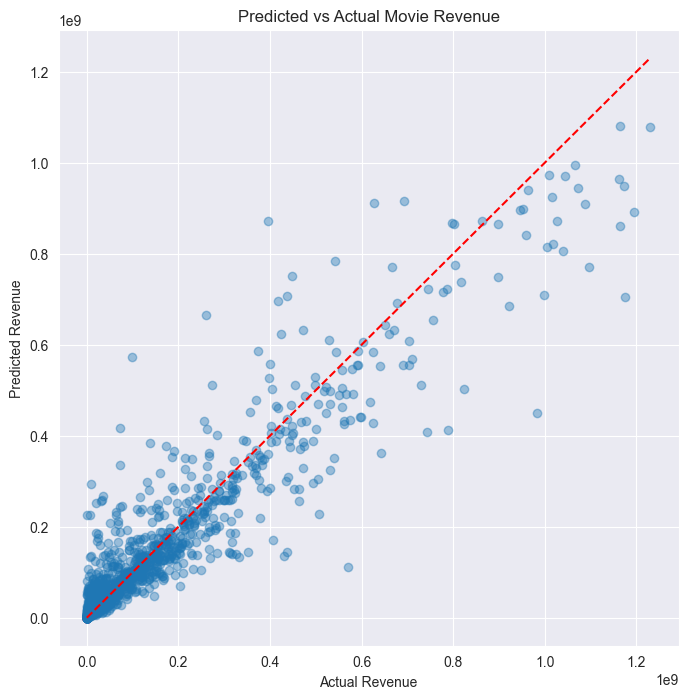

In [65]:
X_train_sample = X_train[importances.index]
X_test_sample = X_test[importances.index]

rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train_sample, y_train)
y_pred = rf.predict(X_test_sample)
mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "random forest",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

Skala logarytmiczna - znaczne pogorszenie wyników

In [43]:
y_log = np.log1p(y)
X_log = X.copy()

X_log['budget_adjusted'] = np.log1p(X_log['budget_adjusted'])
X_log['writer_avg_revenue'] = np.log1p(X_log['writer_avg_revenue'])
X_log['writer_max_revenue'] = np.log1p(X_log['writer_max_revenue'])
X_log['director_avg_revenue'] = np.log1p(X_log['director_avg_revenue'])
X_log['director_max_revenue'] = np.log1p(X_log['director_max_revenue'])
X_log['actors_avg_revenue'] = np.log1p(X_log['actors_avg_revenue'])
X_log['actors_max_revenue'] = np.log1p(X_log['actors_max_revenue'])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=123)

WYNIKI MODELU
R^2 Score: 0.8709
MAE:        $30,475,053.09
RMSE:       $68,426,309.51
std:        $190,440,968.74


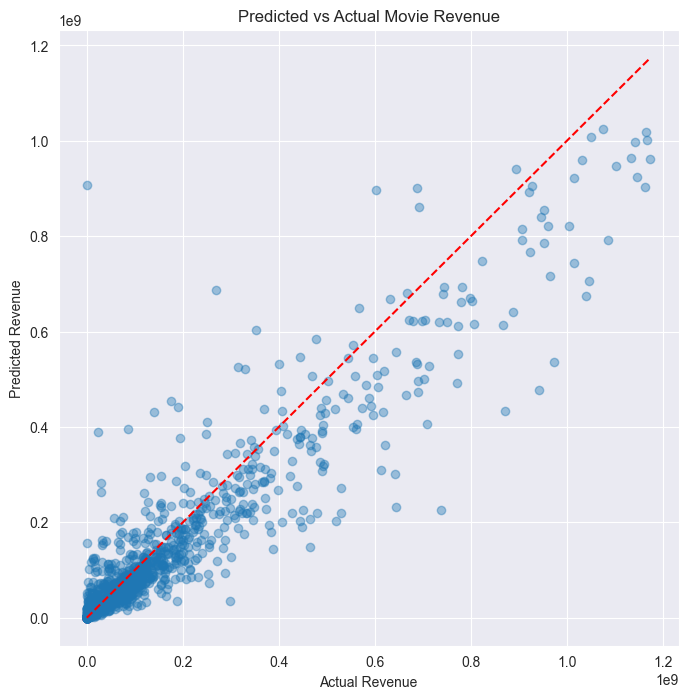

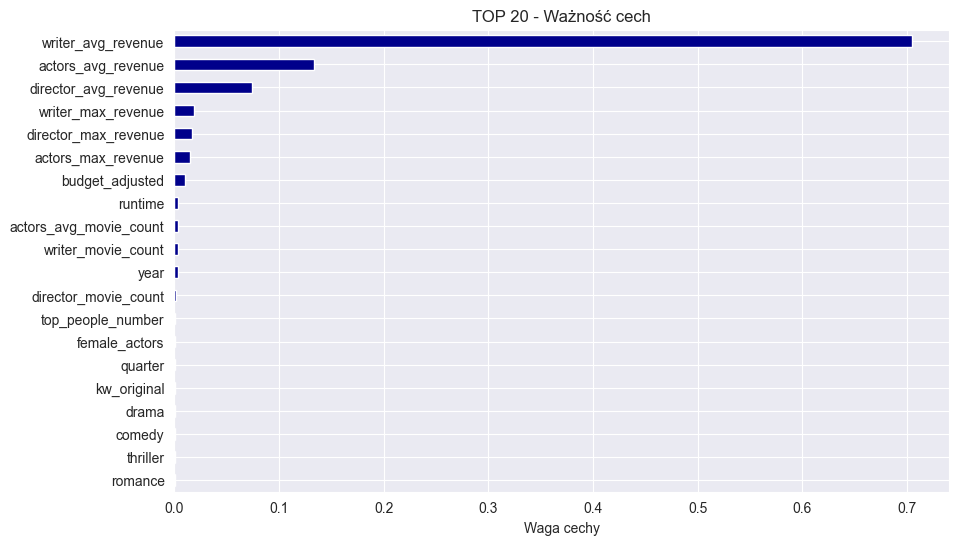

In [69]:
rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train_log, y_train_log)
y_pred_log = rf.predict(X_test_log)

y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)
mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)
scores.append({
    "model": "random forest log",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

importances = pd.Series(rf.feature_importances_, index=X_log.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

Wybór najważniejszych cech - brak poprawy

WYNIKI MODELU
R^2 Score: 0.8720
MAE:        $30,389,108.53
RMSE:       $68,143,680.21
std:        $190,440,968.74


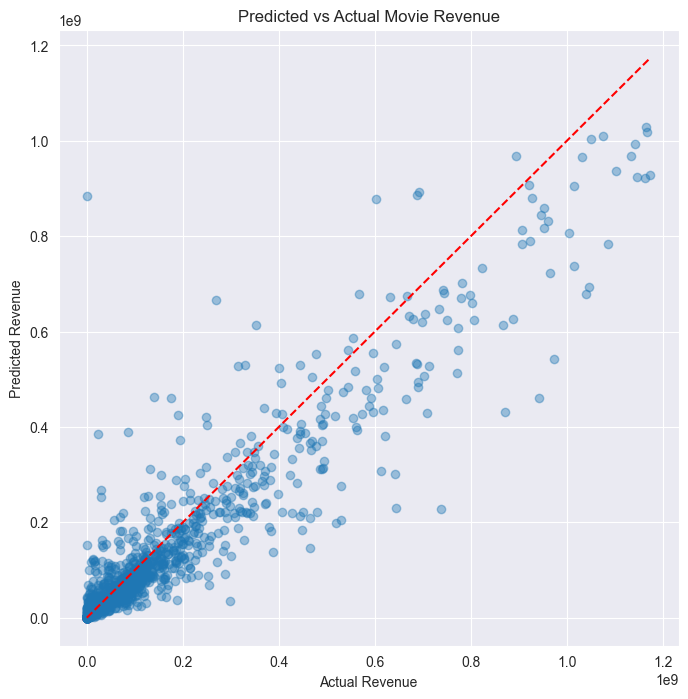

In [19]:
X_train_log_sample = X_train_log[importances.index]
X_test_log_sample = X_test_log[importances.index]

rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train_log_sample, y_train_log)
y_pred_log = rf.predict(X_test_log_sample)

y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)
evaluate_model(y_test_real, y_pred_real)

## XGBoost

WYNIKI MODELU
R^2 Score: 0.8547
MAE:        $31,945,587.44
RMSE:       $70,439,352.57
std:        $184,818,060.44


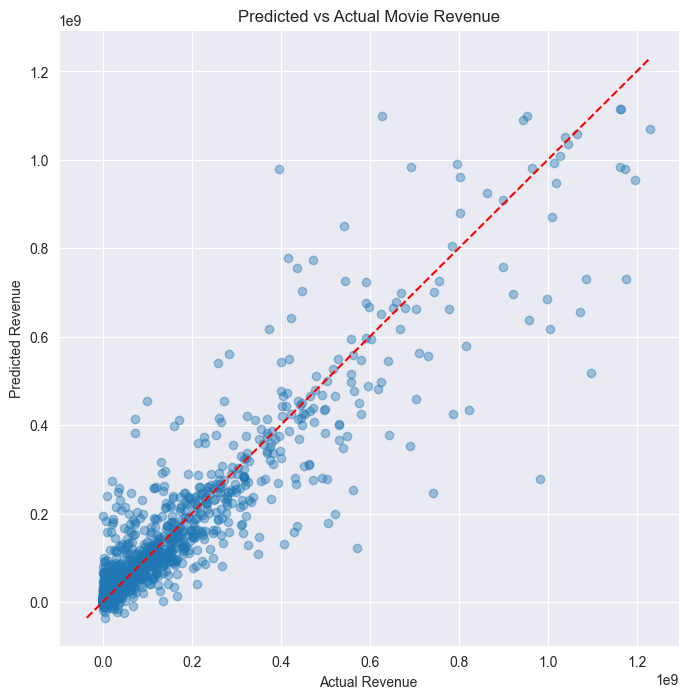

(31945587.439952113, np.float64(70439352.56738715), 0.8547413864631268)

In [66]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

evaluate_model(y_test, y_pred)

In [28]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.1, 0.2],
    "n_estimators": [200, 500, 800],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.1, 0.3]
}

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.9}


Wyniki podobne do Random Forest

WYNIKI MODELU
R^2 Score: 0.8814
MAE:        $28,617,210.19
RMSE:       $63,648,647.54
std:        $184,818,060.44


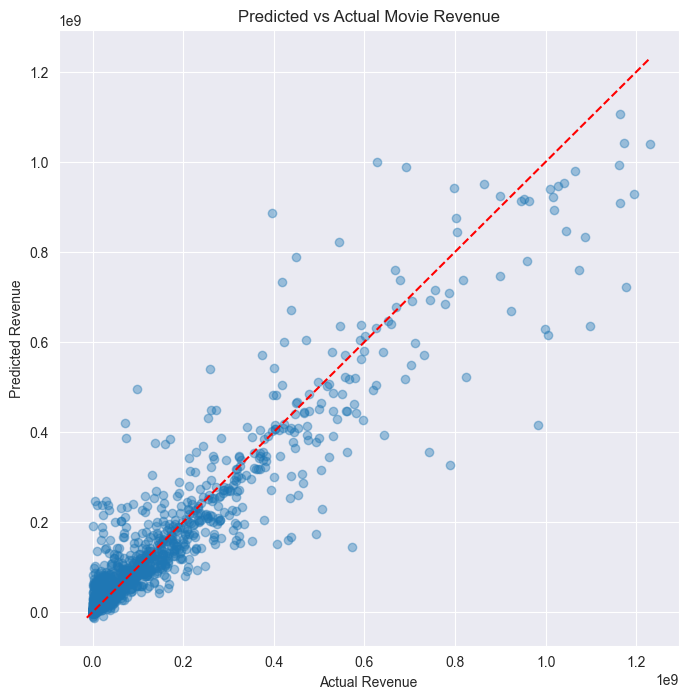

In [67]:
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "xgb",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

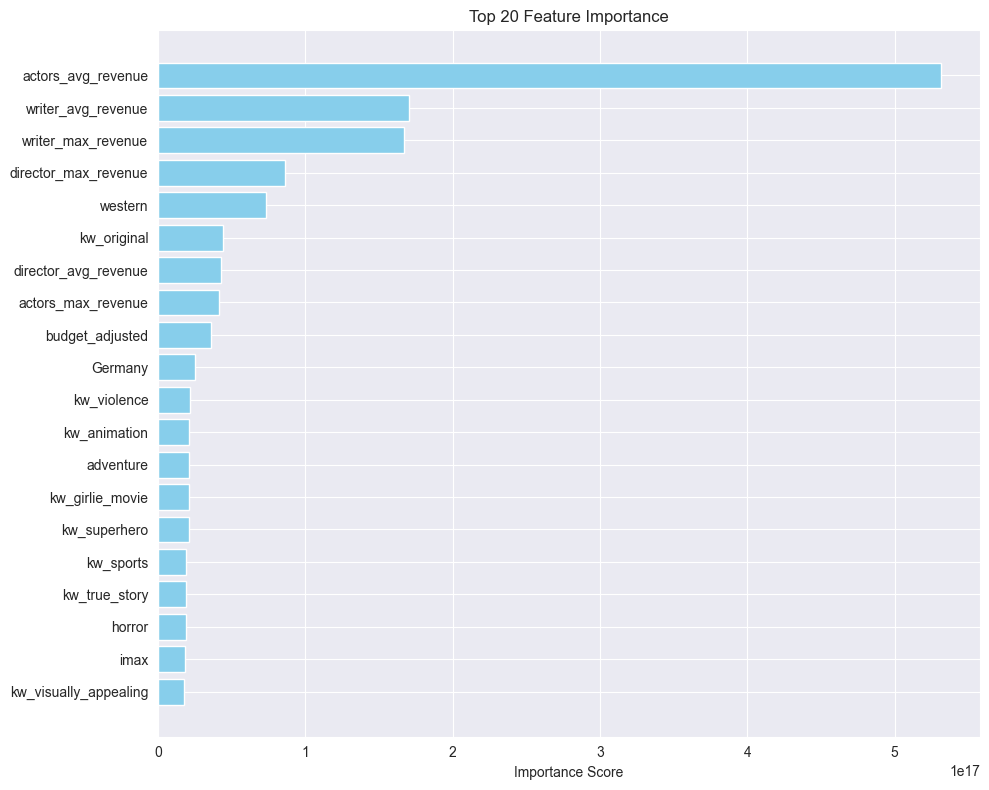

In [13]:
importance = xgb_model.get_booster().get_score(importance_type='gain')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

Wybór najważniejszych cech i dalsze przeszukiwanie przestrzeni hiperparametrów nie przynosi znaczącej poprawy

WYNIKI MODELU
R^2 Score: 0.8802
MAE:        $28,242,080.10
RMSE:       $63,969,862.87
std:        $184,818,060.44


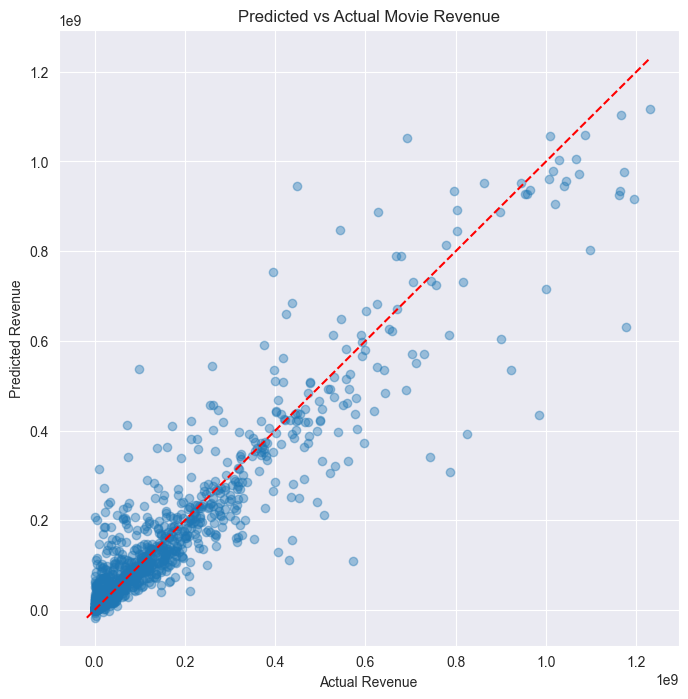

In [16]:
top_features = list(importance_df['Feature'].head(30)[::-1])
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train[top_features], y_train)
y_pred = xgb_model.predict(X_test[top_features])

evaluate_model(y_test, y_pred)

In [32]:
param_grid = {
    "max_depth": [7, 10, 12, 15],
    "learning_rate": [0.0001, 0.001, 0.01, 0.03],
    "n_estimators": [500, 600, 700],
    "subsample": [0.9],
    "colsample_bytree": [0.9],
    "min_child_weight": [1],
    "gamma": [0.3]
}


search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'subsample': 0.9, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.9}


WYNIKI MODELU
R^2 Score: 0.8750
MAE:        $28,609,392.20
RMSE:       $65,343,963.24
std:        $184,818,060.44


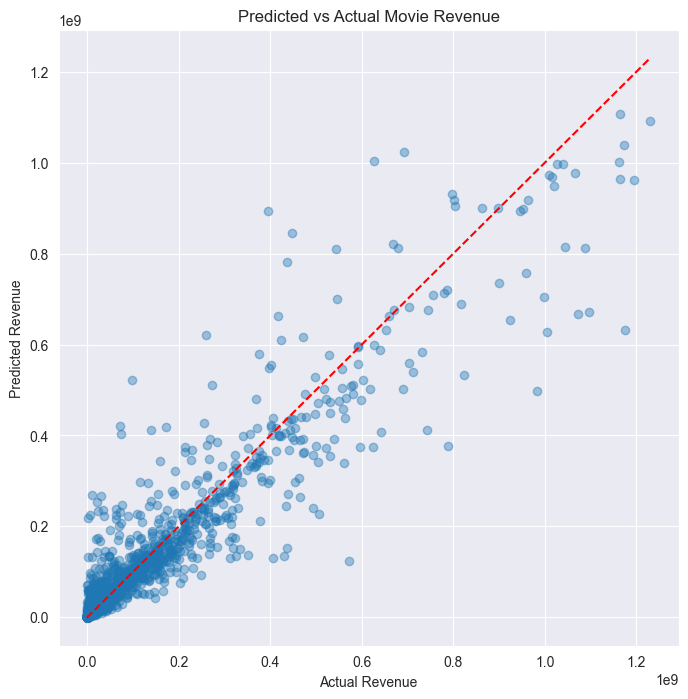

In [33]:
xgb_model = xgb.XGBRegressor(**search.best_params_, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

evaluate_model(y_test, y_pred)

Skala logarytmiczna - ponowne pogorszenie wyników

WYNIKI MODELU
R^2 Score: 0.8599
MAE:        $31,360,594.16
RMSE:       $71,294,549.73
std:        $190,440,968.74


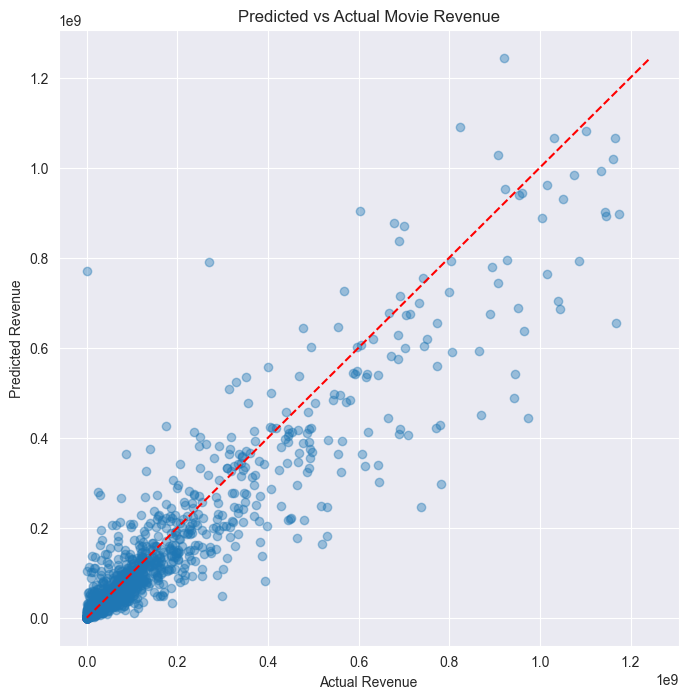

In [68]:
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_log, y_train_log)
y_pred_log = xgb_model.predict(X_test_log)

y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)
mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)
scores.append({
    "model": "xgb log",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

Istotność cech wg SHAP

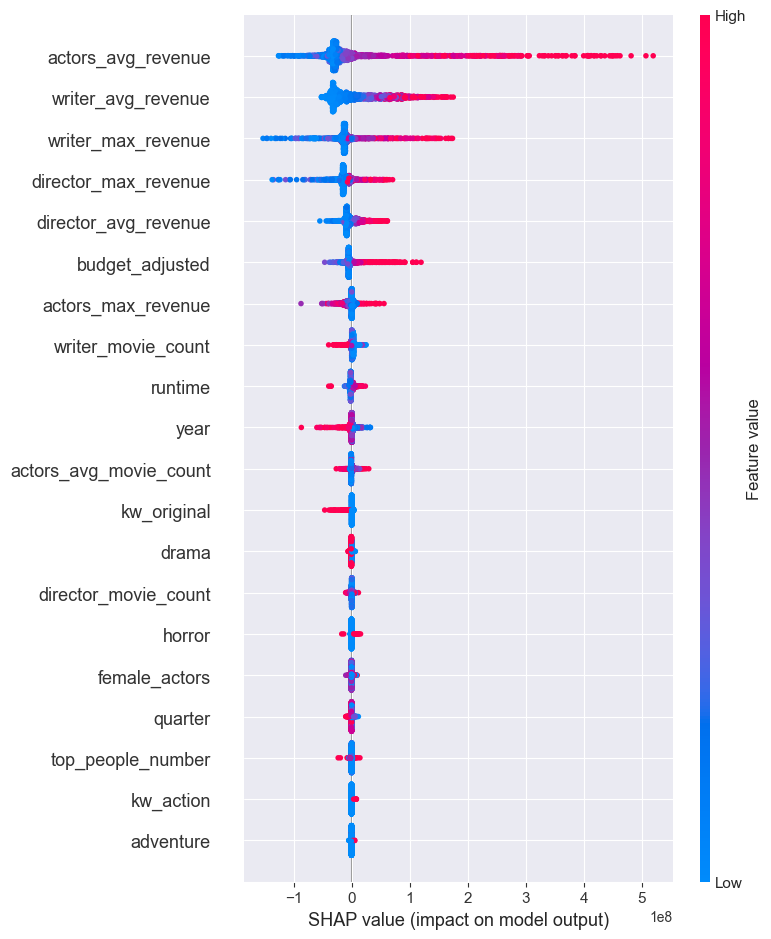

actors_avg_revenue        5.335602e+07
writer_avg_revenue        3.706151e+07
writer_max_revenue        1.890481e+07
director_max_revenue      1.425619e+07
director_avg_revenue      1.015524e+07
budget_adjusted           9.018602e+06
actors_max_revenue        5.752643e+06
writer_movie_count        2.798717e+06
runtime                   2.765090e+06
year                      2.754825e+06
actors_avg_movie_count    1.854260e+06
kw_original               1.148000e+06
drama                     8.771169e+05
director_movie_count      7.926280e+05
horror                    7.302849e+05
female_actors             6.315645e+05
quarter                   6.234138e+05
top_people_number         5.557926e+05
kw_action                 3.545034e+05
adventure                 3.325841e+05
dtype: float32

In [59]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=X_test.columns)
top_features = shap_importance.sort_values(ascending=False).head(20)
top_features

Model XGB z cechami wg SHAP - lekkie pogorszenie

WYNIKI MODELU
R^2 Score: 0.8720
MAE:        $29,146,326.30
RMSE:       $66,134,374.52
std:        $184,818,060.44


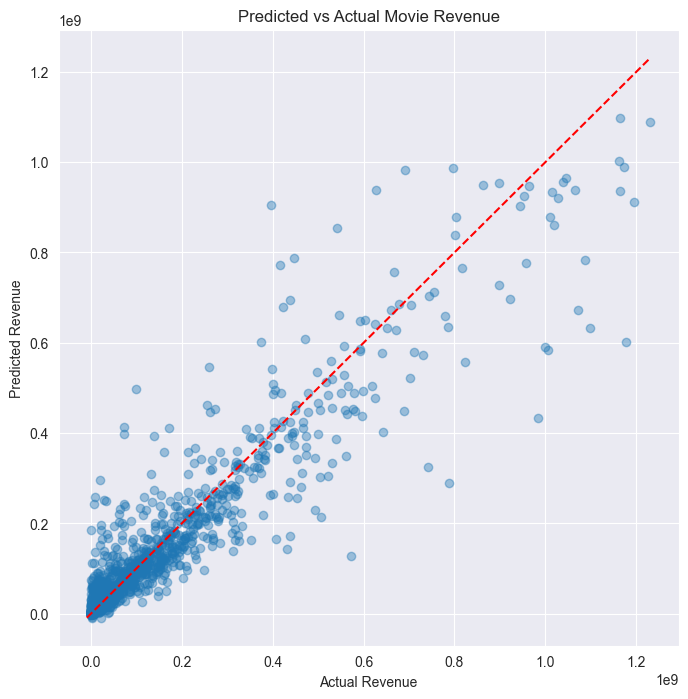

In [76]:
selected_cols = list(top_features.index)

X_train_sel = X_train[selected_cols]
X_test_sel = X_test[selected_cols]

xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train_sel, y_train)
y_pred = xgb_model.predict(X_test_sel)

evaluate_model(y_test, y_pred)

## MLP

Wbudowana klasa z regresorem MLP działa lepiej niż własna architektura przedstawiona niżej, ale i tak wyniki są znacznie gorsze od Random Forest i XGB

WYNIKI MODELU
R^2 Score: 0.8661
MAE:        $31,538,901.54
RMSE:       $67,620,203.66
std:        $184,818,060.44


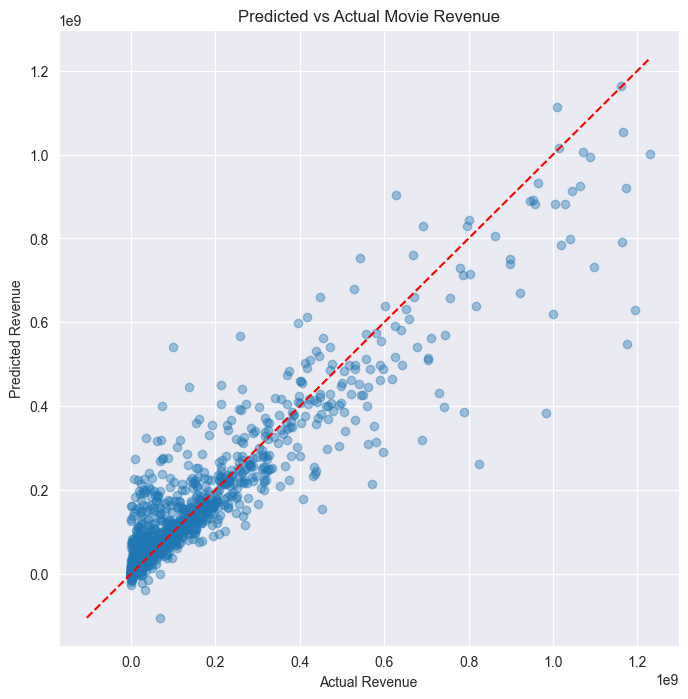

In [7]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(random_state=1, max_iter=2000, tol=0.1)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
evaluate_model(y_test, y_pred)

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

C:\Users\Gabi\PycharmProjects\Data_Exploration\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 44640730433454080.0000 - mae: 106174296.0000 - val_loss: 42024004428496896.0000 - val_mae: 103435408.0000
Epoch 2/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44639467713069056.0000 - mae: 106172336.0000 - val_loss: 42021350138707968.0000 - val_mae: 103431240.0000
Epoch 3/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44634519910744064.0000 - mae: 106164528.0000 - val_loss: 42014113118814208.0000 - val_mae: 103419880.0000
Epoch 4/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44623632168648704.0000 - mae: 106147808.0000 - val_loss: 42000167360004096.0000 - val_mae: 103398072.0000
Epoch 5/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44605288363327488.0000 - mae: 106119248.0000 - val_loss: 41977751925686272.0000 - val_mae: 103363088.0000
Epoch 6/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 44576585096888320.0000 - mae: 106075840.0000 - val_loss: 41945144533975040.0000 - val_mae: 103312288.000

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
WYNIKI MODELU
R^2 Score: 0.7454
MAE:        $52,804,305.76
RMSE:       $93,250,892.83
std:        $184,818,060.44


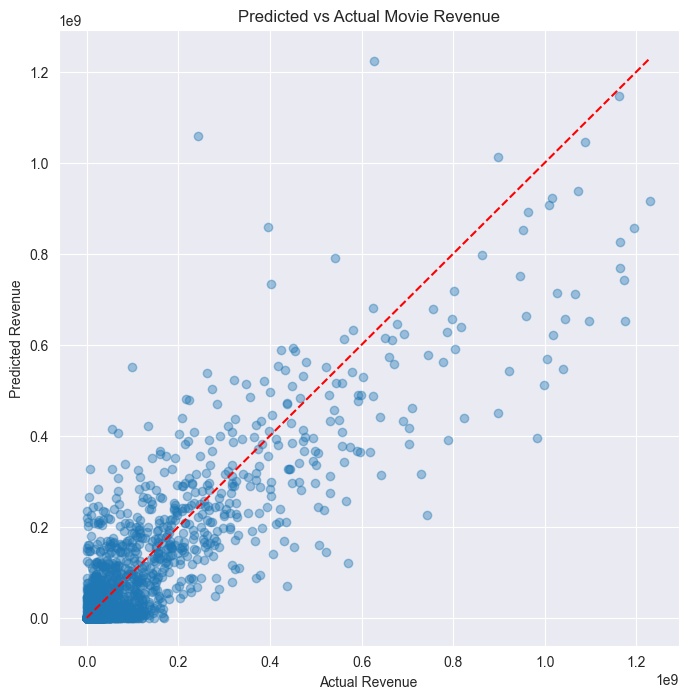

In [62]:
y_pred = model.predict(X_test_scaled)
# y_pred_log = model.predict(X_test_scaled)
# y_pred = np.expm1(y_pred_log).flatten()

mae, rmse, r2 = evaluate_model(y_test, y_pred)
scores.append({
    "model": "mlp",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

Ale nie występuje przeuczenie

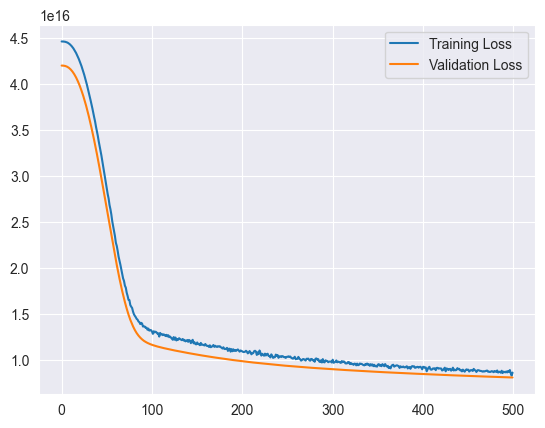

In [53]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

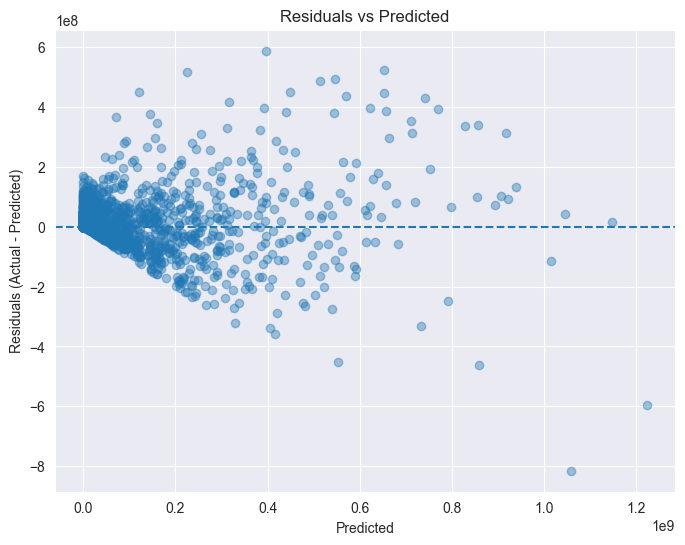

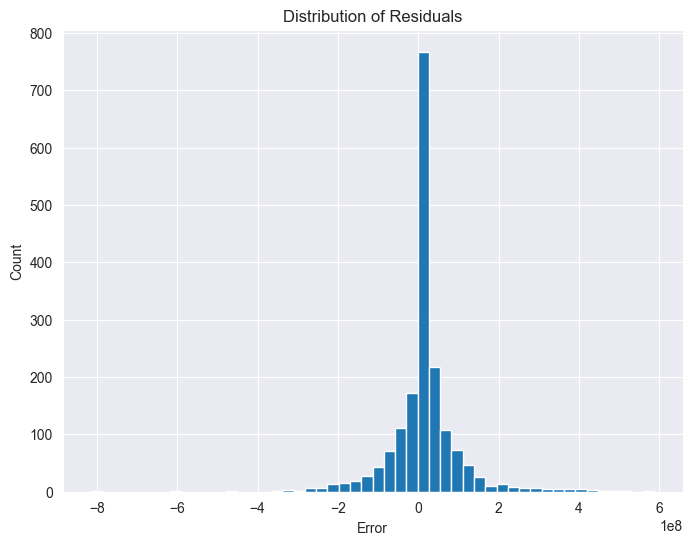

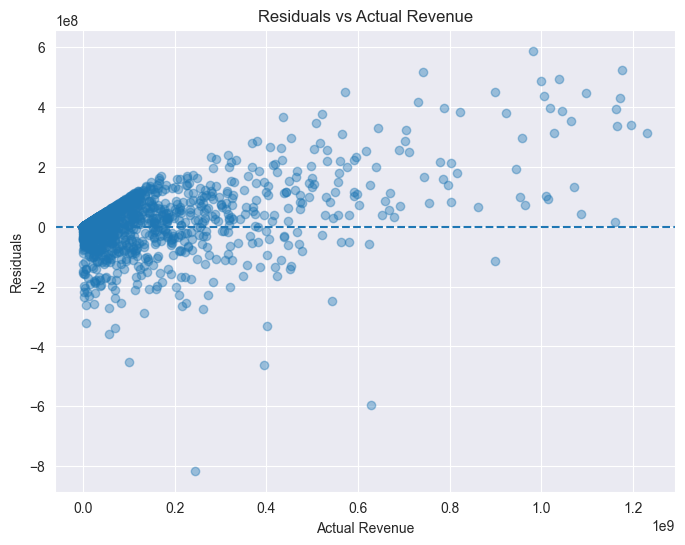

C:\Users\Gabi\AppData\Local\Temp\ipykernel_26192\377124735.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mae_per_bucket = df_eval.groupby("bucket").apply(
C:\Users\Gabi\AppData\Local\Temp\ipykernel_26192\377124735.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_per_bucket = df_eval.groupby("bucket").apply(


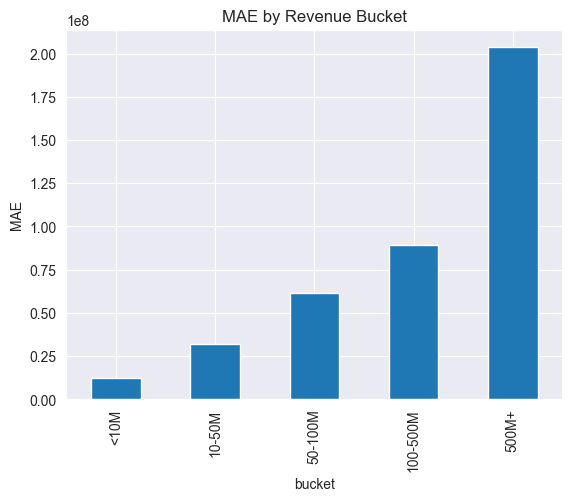

In [59]:
evaluate_model_complex(np.array(y_test).flatten(), np.array(y_pred).flatten())

Skala logarytmiczna - tym razem bardzo znaczne pogorszenie wyników

In [45]:
scaler = StandardScaler()
X_train_scaled_log = scaler.fit_transform(X_train_log)
X_test_scaled_log = scaler.transform(X_test_log)

In [46]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled_log,
    y_train_log,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 32.1224 - mae: 4.0109 - val_loss: 2.4629 - val_mae: 1.2127
Epoch 2/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6857 - mae: 2.0445 - val_loss: 1.9118 - val_mae: 1.0559
Epoch 3/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8489 - mae: 1.9153 - val_loss: 1.8347 - val_mae: 1.0532
Epoch 4/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.1784 - mae: 1.8115 - val_loss: 1.6734 - val_mae: 0.9885
Epoch 5/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8608 - mae: 1.7475 - val_loss: 1.9230 - val_mae: 1.1062
Epoch 6/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.5580 - mae: 1.6871 - val_loss: 1.4720 - val_mae: 0.9189
Epoch 7/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.4075 - mae: 1.6646 - val_loss: 1.3825 - val_mae: 0.8824
Epoch 8/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.3295 - mae: 1.6546 - val_loss: 1.3276 - val_mae: 0.8733
Epoch 9/500
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
WYNIKI MODELU
R^2 Score: 0.4733
MAE:        $50,516,185.46
RMSE:       $138,216,634.57
std:        $190,440,968.74


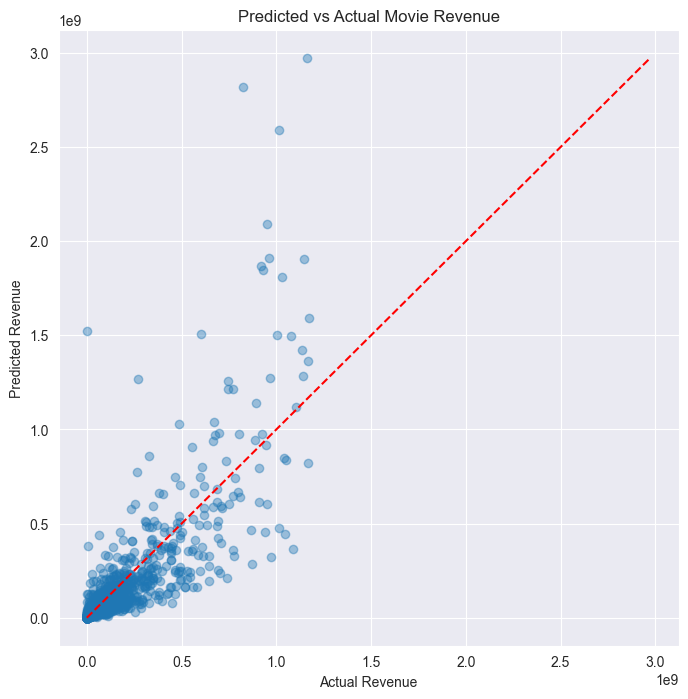

In [47]:
y_pred_log = model.predict(X_test_scaled_log)
y_test_real = np.expm1(y_test_log)
y_pred_real = np.expm1(y_pred_log)

mae, rmse, r2 = evaluate_model(y_test_real, y_pred_real)
scores.append({
    "model": "mlp log",
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
})

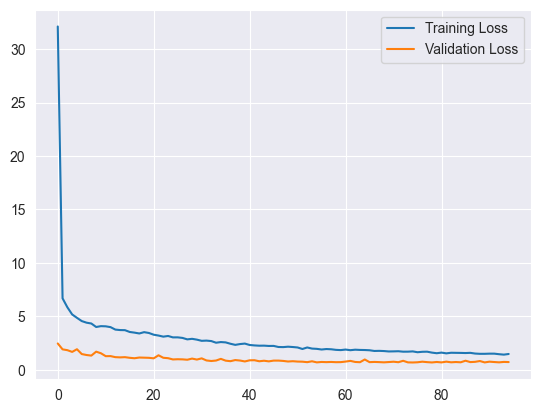

In [48]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [83]:
scores = sorted(scores, key=lambda x: x['mae'])
for model in scores:
    for k, v in model.items():
        if k == "r2":
            print(f"{k}: {v:.4f}")
        elif k in ("mae", "rmse"):
            print(f"{k}: ${v:,.2f}")
        elif k == "model":
            print(v.upper())
        else:
            print(f"{k}: {v}")
    print()

RANDOM FOREST
r2: 0.8836
mae: $28,025,817.77
rmse: $63,051,489.30

XGB
r2: 0.8814
mae: $28,617,210.19
rmse: $63,648,647.54

RANDOM FOREST LOG
r2: 0.8709
mae: $30,475,053.09
rmse: $68,426,309.51

XGB LOG
r2: 0.8599
mae: $31,360,594.16
rmse: $71,294,549.73

MLP LOG
r2: 0.4733
mae: $50,516,185.46
rmse: $138,216,968.74

MLP
r2: 0.7454
mae: $52,804,305.76
rmse: $93,250,892.83

LINEAR REGRESSION
r2: 0.7496
mae: $55,695,428.12
rmse: $92,489,832.89

